In [2]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
X , y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=0)

In [6]:
X

array([[ 1.05241733e+00,  4.54498095e+00],
       [-1.77046905e+00,  3.35250336e+00],
       [-1.83141457e+00,  2.28675420e+00],
       [ 1.36034899e+00,  3.33361370e+00],
       [-1.85497805e-01,  4.41705449e+00],
       [ 9.59360742e-01,  4.56078645e+00],
       [ 5.90099037e-01,  2.96974544e+00],
       [-1.40812364e+00,  3.56704339e+00],
       [-1.39007202e+00,  3.03877023e+00],
       [ 1.42458308e+00,  3.59042035e+00],
       [-2.06534457e+00,  3.70536448e+00],
       [-1.53581864e+00,  3.41072582e+00],
       [-2.04228745e+00,  2.37851697e+00],
       [-8.78078393e-01,  2.53905667e+00],
       [ 1.86725632e-01,  4.02683656e+00],
       [ 9.05371651e-01,  3.89568041e+00],
       [ 2.62109517e+00, -7.46142640e-01],
       [ 2.27421165e+00,  5.10570410e+00],
       [-1.22807257e+00,  2.90216692e+00],
       [ 9.39294237e-01,  4.23940416e+00],
       [ 2.25861000e+00,  2.11028980e+00],
       [ 1.43730635e+00,  6.87697641e-01],
       [ 2.00370906e+00,  1.01423942e+00],
       [-2.

In [8]:
df = pd.DataFrame(X, columns=['X1', 'X2'])
df

,X1,X2
0,1.052417,4.544981
1,-1.770469,3.352503
2,-1.831415,2.286754
3,1.360349,3.333614
4,-0.185498,4.417054
...,...,...
495,2.418340,1.434997
496,2.547461,1.713633
497,2.518111,1.515327
498,0.333819,4.936458


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
inertia = []
K_range = range(1, 11)

In [11]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [12]:
inertia

[1000.0000000000006,
 404.1814840803354,
 138.48971856185548,
 120.03296145328522,
 111.38422447852847,
 95.43625131453744,
 83.62787134261355,
 70.26414440662826,
 58.906179766446435,
 56.11013453595799]

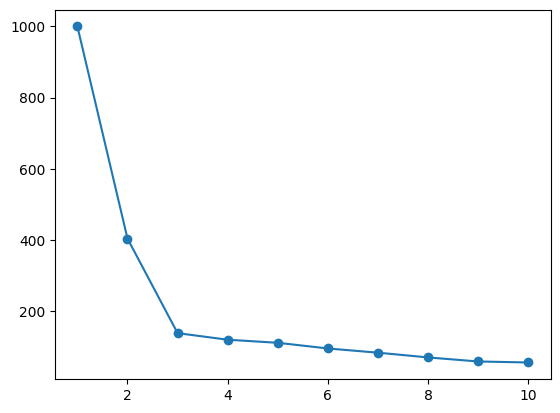

In [13]:
plt.plot(K_range, inertia, marker='o')

In [15]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_label = kmeans_final.fit_predict(X_scaled)

In [16]:
cluster_label

array([2, 1, 1, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 0, 2, 1, 2, 0, 0,
       0, 1, 2, 1, 0, 1, 2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 2, 2, 0,
       0, 2, 0, 2, 1, 1, 2, 2, 2, 2, 1, 1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 1,
       2, 0, 1, 2, 1, 2, 2, 1, 0, 1, 0, 0, 0, 2, 2, 2, 1, 2, 1, 0, 1, 1,
       1, 1, 2, 2, 0, 2, 1, 0, 1, 1, 1, 2, 0, 1, 1, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 0, 1, 1, 0, 1, 0, 0, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2,
       1, 0, 2, 0, 1, 1, 0, 2, 2, 1, 1, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 2,
       0, 2, 1, 0, 1, 2, 0, 0, 1, 1, 1, 0, 2, 0, 2, 0, 1, 1, 0, 2, 2, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 2, 1, 1, 2, 0, 0, 2, 1, 0, 2,
       1, 0, 1, 0, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 0, 1, 1, 2, 1, 2, 1, 1,
       0, 1, 0, 0, 2, 2, 2, 0, 1, 2, 2, 1, 1, 0, 1, 1, 2, 0, 2, 2, 2, 0,
       0, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 2, 0, 1, 0, 0, 2, 2, 0,
       0, 2, 1, 0, 1, 0, 0, 1, 0, 2, 2, 0, 2, 0, 0, 0, 0, 1, 0, 2, 2, 2,
       2, 1, 1, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 0, 2,

In [17]:
df['Cluster'] = cluster_label

<Axes: xlabel='X1', ylabel='X2'>

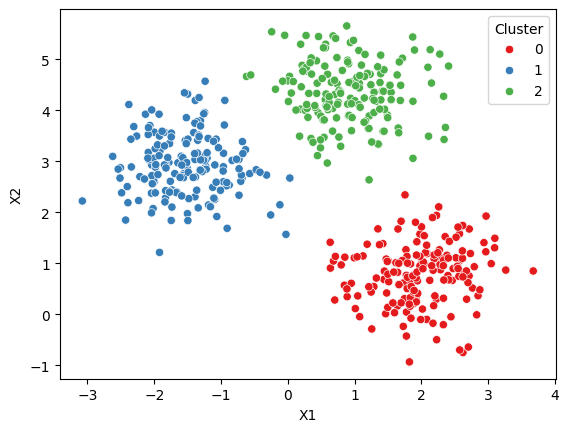

In [19]:
sns.scatterplot(data=df, x='X1', y='X2', hue=df['Cluster'], palette='Set1')